In [ ]:
!pip install mace-torch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.0/316.0 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.1/453.1 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 35.0 MB/s eta 0:00:00
  Created wheel for python-hostlist: filename=python_hostlist-2.3.0-py3-none-any.whl size=39449 sha256=d0f504bc0d580773153e04a16b1b71f9d70e3874d46064a6682b29771a24e03b
  Stored in directory: /root/.cache/pip/wheels/02/e4/34/75fc0cd5b7889d8cc4ce6fb2f74c9fd17b3c6138cb03832481
Successfully built python-hostlist


Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


Running NVE...
  Step 0: T = 296.1 K, E_tot = -436.660 eV
  Step 50: T = 167.9 K, E_tot = -436.647 eV
  Step 100: T = 167.2 K, E_tot = -436.649 eV
  Step 150: T = 140.3 K, E_tot = -436.646 eV
Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/usr/local/lib/python3.12/dist-packages/ase/md/langevin.py:110: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


Running NVT...
  Step 0: T = 274.3 K
  Step 50: T = 312.5 K
  Step 100: T = 258.1 K
  Step 150: T = 279.9 K


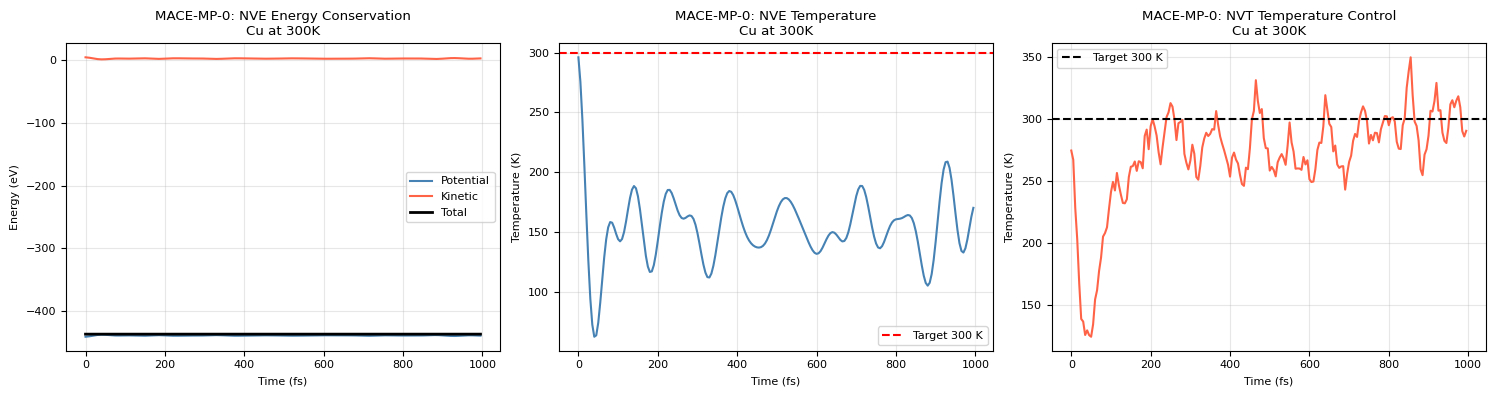

Done.


In [ ]:
from mace.calculators import mace_mp
from ase.build import bulk
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.verlet import VelocityVerlet
from ase.md.langevin import Langevin
from ase import units
import numpy as np
import matplotlib.pyplot as plt

# ── 載入 MACE-MP-0 pretrained model ──────────────
# MACE-MP-0 是用 Materials Project 的 DFT 資料訓練的通用 MLIP
# 可以直接用在週期表上大多數元素，不需要自己訓練
# 相當於：有人已經跑了幾百萬筆 DFT，把結果編碼進這個 model
calc = mace_mp(model="medium", dispersion=False, default_dtype="float32")


# ── 建立 Cu 結構 ──────────────────────────────────
T = 300  # 目標溫度 300K（室溫）
atoms_base = bulk('Cu', 'fcc', a=3.6, cubic=True).repeat(3)  # 108 原子

# ══════════════════════════════════════════════
# Part 1：NVE — 能量守恆模擬
# ══════════════════════════════════════════════
atoms_nve = atoms_base.copy()
atoms_nve.calc = mace_mp(model="medium", dispersion=False, default_dtype="float32")
MaxwellBoltzmannDistribution(atoms_nve, temperature_K=T)

dyn_nve = VelocityVerlet(atoms_nve, timestep=5 * units.fs)

steps = 200
epot_list, ekin_list, etot_list, temp_nve = [], [], [], []

print("Running NVE...")
for i in range(steps):
    dyn_nve.run(1)
    epot = atoms_nve.get_potential_energy()
    ekin = atoms_nve.get_kinetic_energy()
    epot_list.append(epot)
    ekin_list.append(ekin)
    etot_list.append(epot + ekin)
    temp_nve.append(atoms_nve.get_temperature())
    if i % 50 == 0:
        print(f"  Step {i}: T = {temp_nve[-1]:.1f} K, E_tot = {etot_list[-1]:.3f} eV")

# ══════════════════════════════════════════════
# Part 2：NVT — Langevin 控溫模擬
# ══════════════════════════════════════════════
atoms_nvt = atoms_base.copy()
atoms_nvt.calc = mace_mp(model="medium", dispersion=False, default_dtype="float32")
MaxwellBoltzmannDistribution(atoms_nvt, temperature_K=T)

# Langevin thermostat：加入摩擦力與隨機力，強制溫度收斂到 300K
# NVT 下 total energy 不守恆，能量可以和熱浴交換
dyn_nvt = Langevin(atoms_nvt, timestep=5 * units.fs,
                   temperature_K=T, friction=0.01 / units.fs)

temp_nvt = []

print("Running NVT...")
for i in range(steps):
    dyn_nvt.run(1)
    temp_nvt.append(atoms_nvt.get_temperature())
    if i % 50 == 0:
        print(f"  Step {i}: T = {temp_nvt[-1]:.1f} K")

# ══════════════════════════════════════════════
# 畫三張圖
# ══════════════════════════════════════════════
time = np.arange(steps) * 5  # 時間軸，單位 fs

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 圖1：NVE 能量守恆
axes[0].plot(time, epot_list, label='Potential', color='steelblue')
axes[0].plot(time, ekin_list, label='Kinetic', color='tomato')
axes[0].plot(time, etot_list, label='Total', color='black', lw=2)
axes[0].set_xlabel('Time (fs)')
axes[0].set_ylabel('Energy (eV)')
axes[0].set_title('MACE-MP-0: NVE Energy Conservation\nCu at 300K')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 圖2：NVE 溫度波動（無控溫）
axes[1].plot(time, temp_nve, color='steelblue')
axes[1].axhline(T, color='red', linestyle='--', label=f'Target {T} K')
axes[1].set_xlabel('Time (fs)')
axes[1].set_ylabel('Temperature (K)')
axes[1].set_title('MACE-MP-0: NVE Temperature\nCu at 300K')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 圖3：NVT 溫度控制（Langevin 熱浴）
axes[2].plot(time, temp_nvt, color='tomato')
axes[2].axhline(T, color='black', linestyle='--', label=f'Target {T} K')
axes[2].set_xlabel('Time (fs)')
axes[2].set_ylabel('Temperature (K)')
axes[2].set_title('MACE-MP-0: NVT Temperature Control\nCu at 300K')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mace_md_200.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done.")